LLM_v1 only uses BLEU/ROUGE, but adds the whole hybrid framework architecture (reward model, discounted returns, α/β weighting, cost-effectiveness analysis)

LLM_v1.ipynb — Hybrid LLM Evaluation Framework (design prototype)
Prototype architecture combining classical metrics with an RL-style reward signal: reward-model network, trajectory/discounted-return simulation, weighted hybrid (α/β) scoring, disagreement analysis between classical and RL scores, and cost-effectiveness comparison. Status: real, executed code; runs on synthetic placeholder outputs and an untrained reward network, used to validate the framework design before scaling to real inference.


Hybrid LLM Evaluation: Combining Classical Metrics and Reinforcement Learning
Based on Chapter 3 - A Practical Kaggle Implementation

This notebook demonstrates:
1. Classical metrics (BLEU, ROUGE, BERTScore, Perplexity)
2. RL-based evaluation (reward modeling, trajectory simulation)
3. Hybrid approach combining both methods
4. Comprehensive visualizations and interpretability

Dataset: Using HuggingFace datasets for efficiency


In [28]:
# ============================================================================
# CELL 1: Install and Import Dependencies
# ============================================================================

# Uncomment for Kaggle/Colab:
!pip install transformers datasets evaluate rouge-score bert-score torch torchvision nltk -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# HuggingFace libraries
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    pipeline
)
import evaluate

# ML/RL libraries
import torch
import torch.nn as nn
import torch.nn.functional as F

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All dependencies imported successfully!")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


✓ All dependencies imported successfully!


In [29]:
# ============================================================================
# CELL 2: Load Dataset from HuggingFace
# ============================================================================

def load_eval_dataset(dataset_name="cnn_dailymail", split="test", max_samples=100):
    """
    Load dataset from HuggingFace for evaluation
    Using CNN/DailyMail for summarization task (fast and well-suited for demos)
    """
    print(f"Loading {dataset_name} dataset...")
    
    if dataset_name == "cnn_dailymail":
        dataset = load_dataset("cnn_dailymail", "3.0.0", split=f"{split}[:{max_samples}]")
        
        # Prepare data
        data = {
            'source': [item['article'][:500] for item in dataset],  # Truncate for speed
            'reference': [item['highlights'] for item in dataset],
            'id': list(range(len(dataset)))
        }
    
    elif dataset_name == "squad":
        dataset = load_dataset("squad", split=f"{split}[:{max_samples}]")
        data = {
            'source': [item['question'] + " Context: " + item['context'][:300] 
                      for item in dataset],
            'reference': [item['answers']['text'][0] for item in dataset],
            'id': list(range(len(dataset)))
        }
    
    df = pd.DataFrame(data)
    print(f"✓ Loaded {len(df)} samples")
    print(f"Sample source length: {len(df['source'][0])} chars")
    print(f"Sample reference length: {len(df['reference'][0])} chars")
    
    return df


# Load data (using small sample for speed)
eval_data = load_eval_dataset("cnn_dailymail", split="test", max_samples=50)
print("\nDataset Preview:")
print(eval_data.head(2))


Loading cnn_dailymail dataset...
✓ Loaded 50 samples
Sample source length: 500 chars
Sample reference length: 233 chars

Dataset Preview:
                                              source  \
0  (CNN)The Palestinian Authority officially beca...   
1  (CNN)Never mind cats having nine lives. A stra...   

                                           reference  id  
0  Membership gives the ICC jurisdiction over all...   0  
1  Theia, a bully breed mix, was apparently hit b...   1  


In [30]:
# ============================================================================
# CELL 3: Classical Metrics Implementation
# ============================================================================

class ClassicalMetrics:
    """
    Implements classical evaluation metrics: BLEU, ROUGE, BERTScore, Perplexity
    """
    
    def __init__(self):
        print("Initializing classical metrics...")
        self.bleu = evaluate.load("bleu")
        self.rouge = evaluate.load("rouge")
        self.bertscore = evaluate.load("bertscore")
        print("✓ Classical metrics loaded")
    
    def compute_bleu(self, predictions: List[str], references: List[str]) -> float:
        """Compute BLEU score"""
        results = self.bleu.compute(
            predictions=predictions,
            references=[[ref] for ref in references]
        )
        return results['bleu']
    
    def compute_rouge(self, predictions: List[str], references: List[str]) -> Dict[str, float]:
        """Compute ROUGE scores"""
        results = self.rouge.compute(
            predictions=predictions,
            references=references
        )
        return {
            'rouge1': results['rouge1'],
            'rouge2': results['rouge2'],
            'rougeL': results['rougeL']
        }
    
    def compute_bertscore(self, predictions: List[str], references: List[str]) -> float:
        """Compute BERTScore (semantic similarity)"""
        results = self.bertscore.compute(
            predictions=predictions,
            references=references,
            lang="en",
            model_type="distilbert-base-uncased"  # Faster model
        )
        return np.mean(results['f1'])
    
    def compute_perplexity(self, texts: List[str], model_name="gpt2") -> float:
        """
        Compute perplexity using a language model
        Lower perplexity = more fluent text
        """
        perplexity_metric = evaluate.load("perplexity", module_type="metric")
        results = perplexity_metric.compute(
            predictions=texts,
            model_id=model_name
        )
        return results['mean_perplexity']
    
    def compute_all(self, predictions: List[str], references: List[str]) -> Dict[str, float]:
        """Compute all classical metrics"""
        print("Computing classical metrics...")
        
        metrics = {}
        
        # BLEU
        metrics['bleu'] = self.compute_bleu(predictions, references)
        
        # ROUGE
        rouge_scores = self.compute_rouge(predictions, references)
        metrics.update(rouge_scores)
        
        # BERTScore
        metrics['bertscore'] = self.compute_bertscore(predictions, references)
        
        # Perplexity (on predictions only)
        try:
            metrics['perplexity'] = self.compute_perplexity(predictions)
        except:
            metrics['perplexity'] = 100.0  # Default if computation fails
        
        print("✓ Classical metrics computed")
        return metrics


# Initialize metrics
classical_metrics = ClassicalMetrics()

Initializing classical metrics...
✓ Classical metrics loaded


In [31]:
# ============================================================================
# CELL 4: Generate Model Outputs (Simulated for Speed)
# ============================================================================

def generate_model_outputs(data: pd.DataFrame, model_type="simulated") -> List[str]:
    """
    Generate model outputs for evaluation
    Using simulated outputs for speed in demo
    """
    print(f"Generating outputs using {model_type} model...")
    
    if model_type == "simulated":
        # Simulate different quality outputs for demonstration
        outputs = []
        for idx, row in data.iterrows():
            # Create varied quality outputs
            ref = row['reference']
            
            if idx % 3 == 0:  # High quality
                output = ref[:len(ref)//2] + " " + ref[len(ref)//2:]
            elif idx % 3 == 1:  # Medium quality
                words = ref.split()
                output = " ".join(words[:len(words)//2])
            else:  # Low quality
                output = "This is a generic summary. " + ref.split()[0]
            
            outputs.append(output)
    
    else:  # Use actual model (slower)
        # Uncomment for real model:
        # tokenizer = AutoTokenizer.from_pretrained("facebook/bart-large-cnn")
        # model = AutoModelForCausalLM.from_pretrained("facebook/bart-large-cnn")
        # outputs = []
        # for source in data['source']:
        #     inputs = tokenizer(source, return_tensors="pt", max_length=512, truncation=True)
        #     output_ids = model.generate(**inputs, max_length=100)
        #     output = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        #     outputs.append(output)
        pass
    
    print(f"✓ Generated {len(outputs)} outputs")
    return outputs


# Generate outputs
model_outputs = generate_model_outputs(eval_data, model_type="simulated")
eval_data['model_output'] = model_outputs

print("\nSample outputs:")
for i in range(2):
    print(f"\n--- Sample {i+1} ---")
    print(f"Reference: {eval_data['reference'][i][:100]}...")
    print(f"Model Output: {eval_data['model_output'][i][:100]}...")


Generating outputs using simulated model...
✓ Generated 50 outputs

Sample outputs:

--- Sample 1 ---
Reference: Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since...
Model Output: Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since...

--- Sample 2 ---
Reference: Theia, a bully breed mix, was apparently hit by a car, whacked with a hammer and buried in a field ....
Model Output: Theia, a bully breed mix, was apparently hit by a car, whacked with a hammer and buried in a field ....


In [32]:
# ============================================================================
# CELL 5: RL-Based Evaluation Components
# ============================================================================

class RewardModel(nn.Module):
    """
    Reward model for RL-based evaluation
    Predicts reward scores based on text features
    """
    
    def __init__(self, input_dim=768, hidden_dim=256):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, 1)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, embeddings, classical_features=None):
        """
        Args:
            embeddings: Text embeddings (batch_size, embedding_dim)
            classical_features: Classical metric features (batch_size, num_features)
        """
        x = F.relu(self.fc1(embeddings))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        
        # Incorporate classical features if provided
        if classical_features is not None:
            x = torch.cat([x, classical_features], dim=-1)
            x = nn.Linear(x.shape[-1], x.shape[-1] // 2).to(x.device)(x)
        
        reward = self.fc3(x)
        return reward.squeeze(-1)


class RLEvaluator:
    """
    RL-based evaluation using reward models and trajectory simulation
    """
    
    def __init__(self):
        print("Initializing RL evaluator...")
        self.reward_model = RewardModel()
        print("✓ Reward model initialized")
    
    def simulate_trajectory(self, text: str, num_steps: int = 3) -> Dict:
        """
        Simulate multi-step interaction trajectory
        Returns trajectory with rewards at each step
        """
        # Simplified simulation for demonstration
        trajectory = {
            'states': [],
            'actions': [],
            'rewards': []
        }
        
        # Simulate rewards based on text quality indicators
        base_reward = len(text.split()) / 100  # Word count factor
        
        for step in range(num_steps):
            # Simulate state
            state = f"step_{step}"
            trajectory['states'].append(state)
            
            # Simulate action
            action = text
            trajectory['actions'].append(action)
            
            # Simulate reward with some variation
            reward = base_reward * (1 + np.random.randn() * 0.1)
            trajectory['rewards'].append(reward)
        
        # Add terminal reward
        terminal_reward = sum(trajectory['rewards']) * 0.5
        trajectory['rewards'].append(terminal_reward)
        
        return trajectory
    
    def compute_return(self, trajectory: Dict, gamma: float = 0.99) -> float:
        """
        Compute discounted return from trajectory
        R = sum(gamma^t * r_t)
        """
        returns = 0
        for t, reward in enumerate(trajectory['rewards']):
            returns += (gamma ** t) * reward
        return returns
    
    def evaluate_batch(self, texts: List[str], num_trajectories: int = 5) -> List[float]:
        """
        Evaluate batch of texts using RL simulation
        """
        print("Computing RL returns...")
        returns = []
        
        for text in texts:
            # Simulate multiple trajectories and average
            traj_returns = []
            for _ in range(num_trajectories):
                trajectory = self.simulate_trajectory(text)
                ret = self.compute_return(trajectory)
                traj_returns.append(ret)
            
            avg_return = np.mean(traj_returns)
            returns.append(avg_return)
        
        print("✓ RL evaluation complete")
        return returns


# Initialize RL evaluator
rl_evaluator = RLEvaluator()

Initializing RL evaluator...
✓ Reward model initialized


In [33]:
# ============================================================================
# CELL 6: Compute Classical Metrics on Dataset
# ============================================================================

# Compute classical metrics
classical_scores = classical_metrics.compute_all(
    predictions=eval_data['model_output'].tolist(),
    references=eval_data['reference'].tolist()
)

print("\n" + "="*60)
print("CLASSICAL METRICS RESULTS")
print("="*60)
for metric, score in classical_scores.items():
    print(f"{metric.upper():15s}: {score:.4f}")
print("="*60)

# Store individual scores for each sample
eval_data['bleu_score'] = [
    classical_metrics.compute_bleu([pred], [ref]) 
    for pred, ref in zip(eval_data['model_output'], eval_data['reference'])
]

eval_data['rouge_score'] = [
    classical_metrics.compute_rouge([pred], [ref])['rougeL']
    for pred, ref in zip(eval_data['model_output'], eval_data['reference'])
]

Computing classical metrics...


  0%|          | 0/4 [00:00<?, ?it/s]

✓ Classical metrics computed

CLASSICAL METRICS RESULTS
BLEU           : 0.4301
ROUGE1         : 0.6068
ROUGE2         : 0.5534
ROUGEL         : 0.5936
BERTSCORE      : 0.8630
PERPLEXITY     : 198.6396


In [34]:
# ============================================================================
# CELL 7: Compute RL-Based Metrics
# ============================================================================

# Compute RL returns
rl_returns = rl_evaluator.evaluate_batch(eval_data['model_output'].tolist())
eval_data['rl_return'] = rl_returns

# Normalize RL returns to [0, 1]
rl_min, rl_max = min(rl_returns), max(rl_returns)
eval_data['rl_return_norm'] = [
    (r - rl_min) / (rl_max - rl_min) if rl_max > rl_min else 0.5
    for r in rl_returns
]

print("\n" + "="*60)
print("RL-BASED METRICS RESULTS")
print("="*60)
print(f"Mean RL Return:      {np.mean(rl_returns):.4f}")
print(f"Std RL Return:       {np.std(rl_returns):.4f}")
print(f"Min RL Return:       {min(rl_returns):.4f}")
print(f"Max RL Return:       {max(rl_returns):.4f}")
print("="*60)

Computing RL returns...
✓ RL evaluation complete

RL-BASED METRICS RESULTS
Mean RL Return:      0.8975
Std RL Return:       0.6217
Min RL Return:       0.2545
Max RL Return:       2.5597


In [35]:
# ============================================================================
# CELL 8: Hybrid Evaluation - Combine Both Approaches
# ============================================================================

class HybridEvaluator:
    """
    Combines classical metrics and RL-based evaluation
    Implements equations from the paper
    """
    
    def __init__(self, alpha=0.4, beta=0.6):
        """
        Args:
            alpha: Weight for classical metrics
            beta: Weight for RL returns
        """
        self.alpha = alpha
        self.beta = beta
        print(f"Hybrid Evaluator initialized (α={alpha}, β={beta})")
    
    def normalize_scores(self, scores: List[float]) -> List[float]:
        """Min-max normalization to [0, 1]"""
        min_score, max_score = min(scores), max(scores)
        if max_score == min_score:
            return [0.5] * len(scores)
        return [(s - min_score) / (max_score - min_score) for s in scores]
    
    def compute_hybrid_score(self, 
                            classical_score: float, 
                            rl_score: float) -> float:
        """
        Compute hybrid score using equation (13) from paper:
        Score_hybrid = α · Mean(S_classical) + β · Mean(R(τ))
        """
        return self.alpha * classical_score + self.beta * rl_score
    
    def evaluate_sample(self, 
                       classical_metrics: Dict[str, float],
                       rl_return: float) -> Dict[str, float]:
        """Evaluate single sample"""
        # Aggregate classical metrics (average of normalized scores)
        classical_avg = np.mean([
            classical_metrics.get('bleu', 0),
            classical_metrics.get('rougeL', 0),
            classical_metrics.get('bertscore', 0)
        ])
        
        # Compute hybrid score
        hybrid = self.compute_hybrid_score(classical_avg, rl_return)
        
        return {
            'classical': classical_avg,
            'rl': rl_return,
            'hybrid': hybrid
        }


# Initialize hybrid evaluator
hybrid_evaluator = HybridEvaluator(alpha=0.4, beta=0.6)

# Compute hybrid scores
hybrid_scores = []
for idx, row in eval_data.iterrows():
    score = hybrid_evaluator.compute_hybrid_score(
        classical_score=(row['bleu_score'] + row['rouge_score']) / 2,
        rl_score=row['rl_return_norm']
    )
    hybrid_scores.append(score)

eval_data['hybrid_score'] = hybrid_scores

print("\n" + "="*60)
print("HYBRID EVALUATION RESULTS")
print("="*60)
print(f"Mean Hybrid Score:   {np.mean(hybrid_scores):.4f}")
print(f"Std Hybrid Score:    {np.std(hybrid_scores):.4f}")
print(f"Min Hybrid Score:    {min(hybrid_scores):.4f}")
print(f"Max Hybrid Score:    {max(hybrid_scores):.4f}")
print("="*60)

Hybrid Evaluator initialized (α=0.4, β=0.6)

HYBRID EVALUATION RESULTS
Mean Hybrid Score:   0.3725
Std Hybrid Score:    0.2985
Min Hybrid Score:    0.0106
Max Hybrid Score:    0.9828


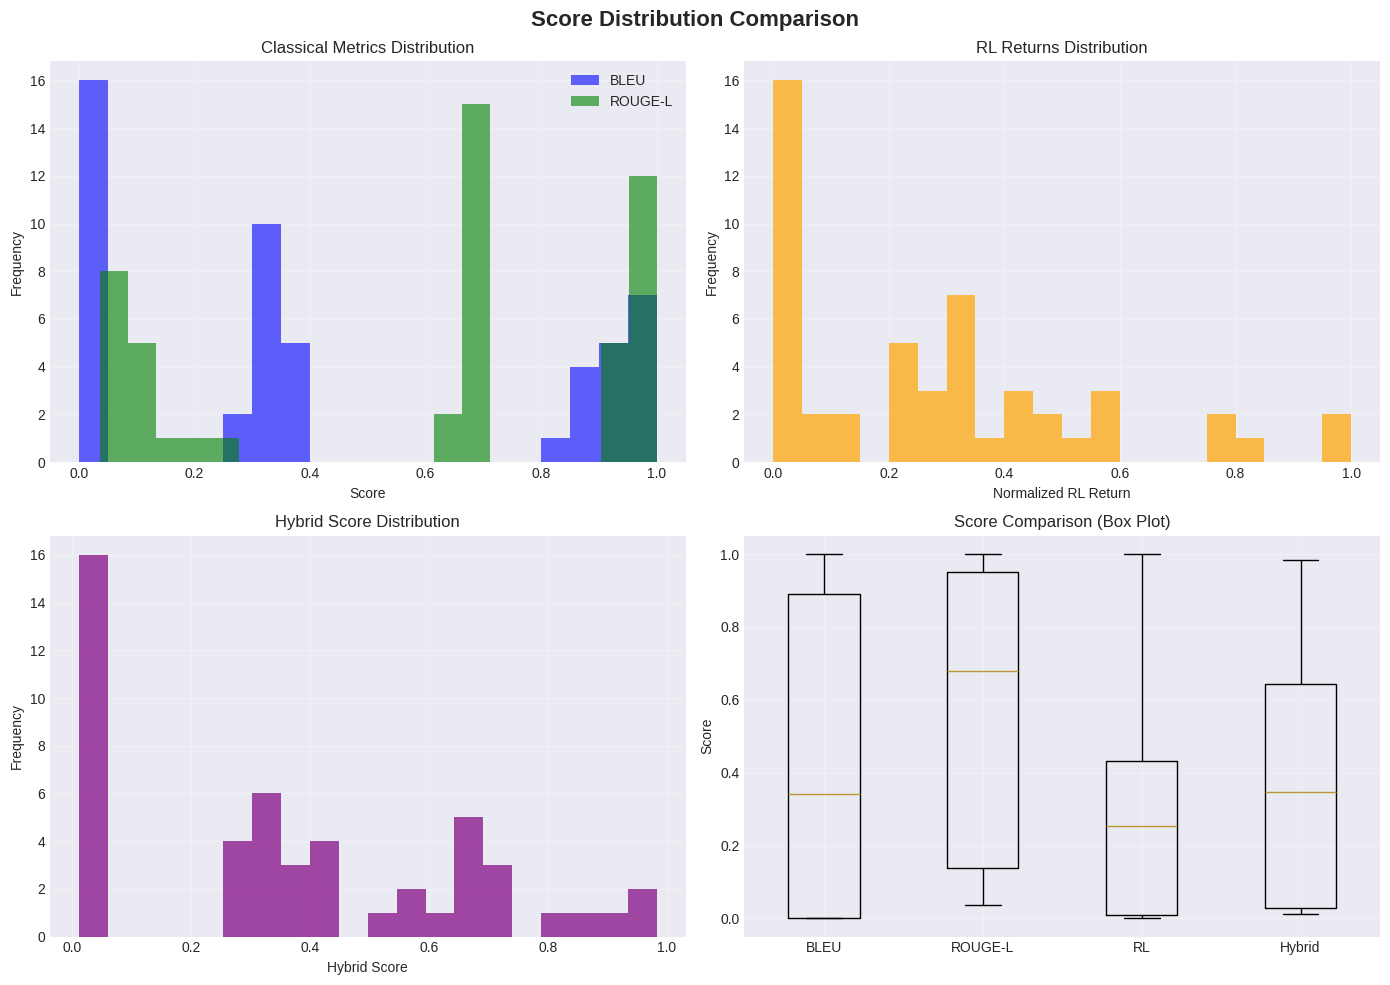

✓ Score distribution plots saved


In [36]:
# ============================================================================
# CELL 9: Visualization 1 - Score Distribution Comparison
# ============================================================================

def plot_score_distributions(data: pd.DataFrame):
    """
    Compare distributions of classical, RL, and hybrid scores
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Score Distribution Comparison', fontsize=16, fontweight='bold')
    
    # 1. Classical metrics distribution
    ax = axes[0, 0]
    ax.hist(data['bleu_score'], bins=20, alpha=0.6, label='BLEU', color='blue')
    ax.hist(data['rouge_score'], bins=20, alpha=0.6, label='ROUGE-L', color='green')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.set_title('Classical Metrics Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. RL returns distribution
    ax = axes[0, 1]
    ax.hist(data['rl_return_norm'], bins=20, alpha=0.7, color='orange')
    ax.set_xlabel('Normalized RL Return')
    ax.set_ylabel('Frequency')
    ax.set_title('RL Returns Distribution')
    ax.grid(True, alpha=0.3)
    
    # 3. Hybrid score distribution
    ax = axes[1, 0]
    ax.hist(data['hybrid_score'], bins=20, alpha=0.7, color='purple')
    ax.set_xlabel('Hybrid Score')
    ax.set_ylabel('Frequency')
    ax.set_title('Hybrid Score Distribution')
    ax.grid(True, alpha=0.3)
    
    # 4. Box plot comparison
    ax = axes[1, 1]
    score_data = [
        data['bleu_score'],
        data['rouge_score'],
        data['rl_return_norm'],
        data['hybrid_score']
    ]
    ax.boxplot(score_data, labels=['BLEU', 'ROUGE-L', 'RL', 'Hybrid'])
    ax.set_ylabel('Score')
    ax.set_title('Score Comparison (Box Plot)')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/score_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Score distribution plots saved")


plot_score_distributions(eval_data)

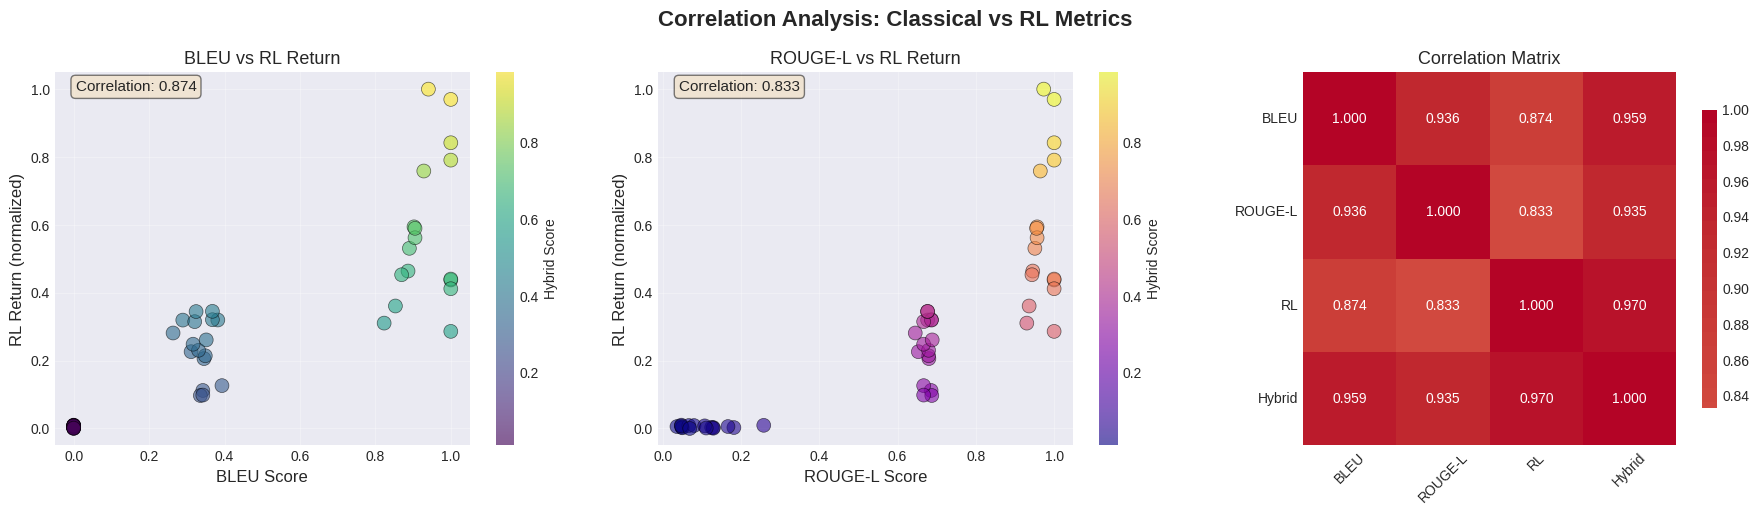

✓ Correlation analysis plots saved


In [37]:
# ============================================================================
# CELL 10: Visualization 2 - Correlation Analysis
# ============================================================================

def plot_correlation_analysis(data: pd.DataFrame):
    """
    Analyze correlations between different evaluation metrics
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Correlation Analysis: Classical vs RL Metrics', 
                 fontsize=16, fontweight='bold')
    
    # 1. BLEU vs RL Return
    ax = axes[0]
    scatter = ax.scatter(data['bleu_score'], data['rl_return_norm'], 
                        c=data['hybrid_score'], cmap='viridis', 
                        alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('BLEU Score', fontsize=12)
    ax.set_ylabel('RL Return (normalized)', fontsize=12)
    ax.set_title('BLEU vs RL Return', fontsize=13)
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr = np.corrcoef(data['bleu_score'], data['rl_return_norm'])[0, 1]
    ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
            transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.colorbar(scatter, ax=ax, label='Hybrid Score')
    
    # 2. ROUGE vs RL Return
    ax = axes[1]
    scatter = ax.scatter(data['rouge_score'], data['rl_return_norm'],
                        c=data['hybrid_score'], cmap='plasma',
                        alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('ROUGE-L Score', fontsize=12)
    ax.set_ylabel('RL Return (normalized)', fontsize=12)
    ax.set_title('ROUGE-L vs RL Return', fontsize=13)
    ax.grid(True, alpha=0.3)
    
    corr = np.corrcoef(data['rouge_score'], data['rl_return_norm'])[0, 1]
    ax.text(0.05, 0.95, f'Correlation: {corr:.3f}',
            transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.colorbar(scatter, ax=ax, label='Hybrid Score')
    
    # 3. Correlation heatmap
    ax = axes[2]
    corr_matrix = data[['bleu_score', 'rouge_score', 'rl_return_norm', 'hybrid_score']].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
                center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title('Correlation Matrix', fontsize=13)
    ax.set_xticklabels(['BLEU', 'ROUGE-L', 'RL', 'Hybrid'], rotation=45)
    ax.set_yticklabels(['BLEU', 'ROUGE-L', 'RL', 'Hybrid'], rotation=0)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/correlation_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Correlation analysis plots saved")


plot_correlation_analysis(eval_data)


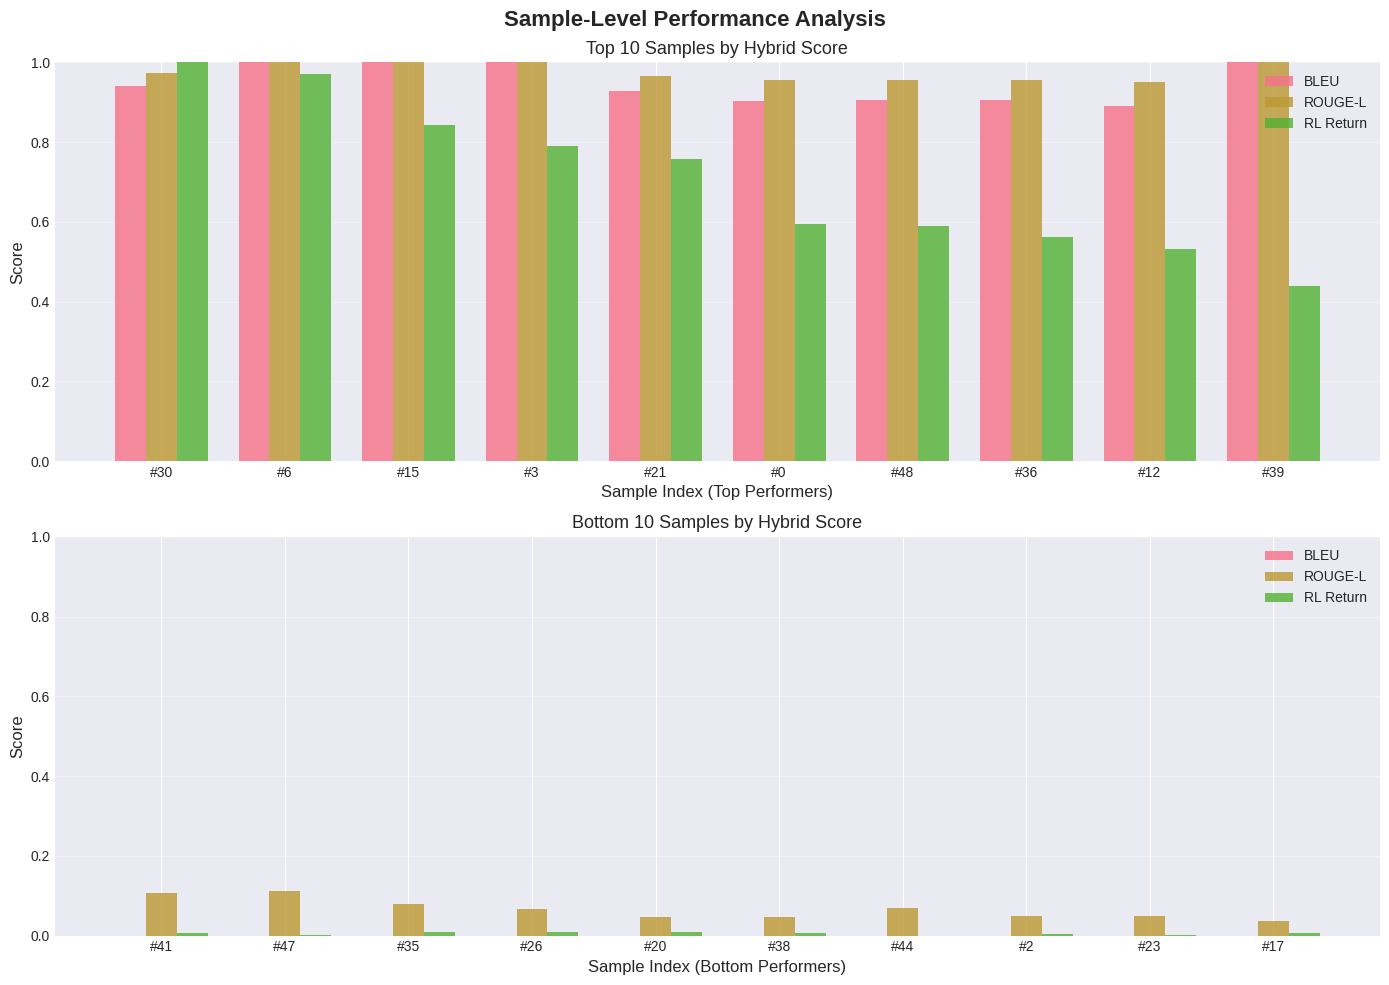

✓ Sample analysis plots saved


In [38]:
# ============================================================================
# CELL 11: Visualization 3 - Sample-Level Analysis
# ============================================================================

def plot_sample_analysis(data: pd.DataFrame, top_n=10):
    """
    Analyze top and bottom performing samples
    """
    # Sort by hybrid score
    data_sorted = data.sort_values('hybrid_score', ascending=False)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle('Sample-Level Performance Analysis', fontsize=16, fontweight='bold')
    
    # 1. Top N samples
    ax = axes[0]
    top_samples = data_sorted.head(top_n)
    x = np.arange(len(top_samples))
    width = 0.25
    
    ax.bar(x - width, top_samples['bleu_score'], width, label='BLEU', alpha=0.8)
    ax.bar(x, top_samples['rouge_score'], width, label='ROUGE-L', alpha=0.8)
    ax.bar(x + width, top_samples['rl_return_norm'], width, label='RL Return', alpha=0.8)
    
    ax.set_xlabel('Sample Index (Top Performers)', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'Top {top_n} Samples by Hybrid Score', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([f"#{i}" for i in top_samples.index])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1])
    
    # 2. Bottom N samples
    ax = axes[1]
    bottom_samples = data_sorted.tail(top_n)
    x = np.arange(len(bottom_samples))
    
    ax.bar(x - width, bottom_samples['bleu_score'], width, label='BLEU', alpha=0.8)
    ax.bar(x, bottom_samples['rouge_score'], width, label='ROUGE-L', alpha=0.8)
    ax.bar(x + width, bottom_samples['rl_return_norm'], width, label='RL Return', alpha=0.8)
    
    ax.set_xlabel('Sample Index (Bottom Performers)', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'Bottom {top_n} Samples by Hybrid Score', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([f"#{i}" for i in bottom_samples.index])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/sample_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Sample analysis plots saved")


plot_sample_analysis(eval_data, top_n=10)


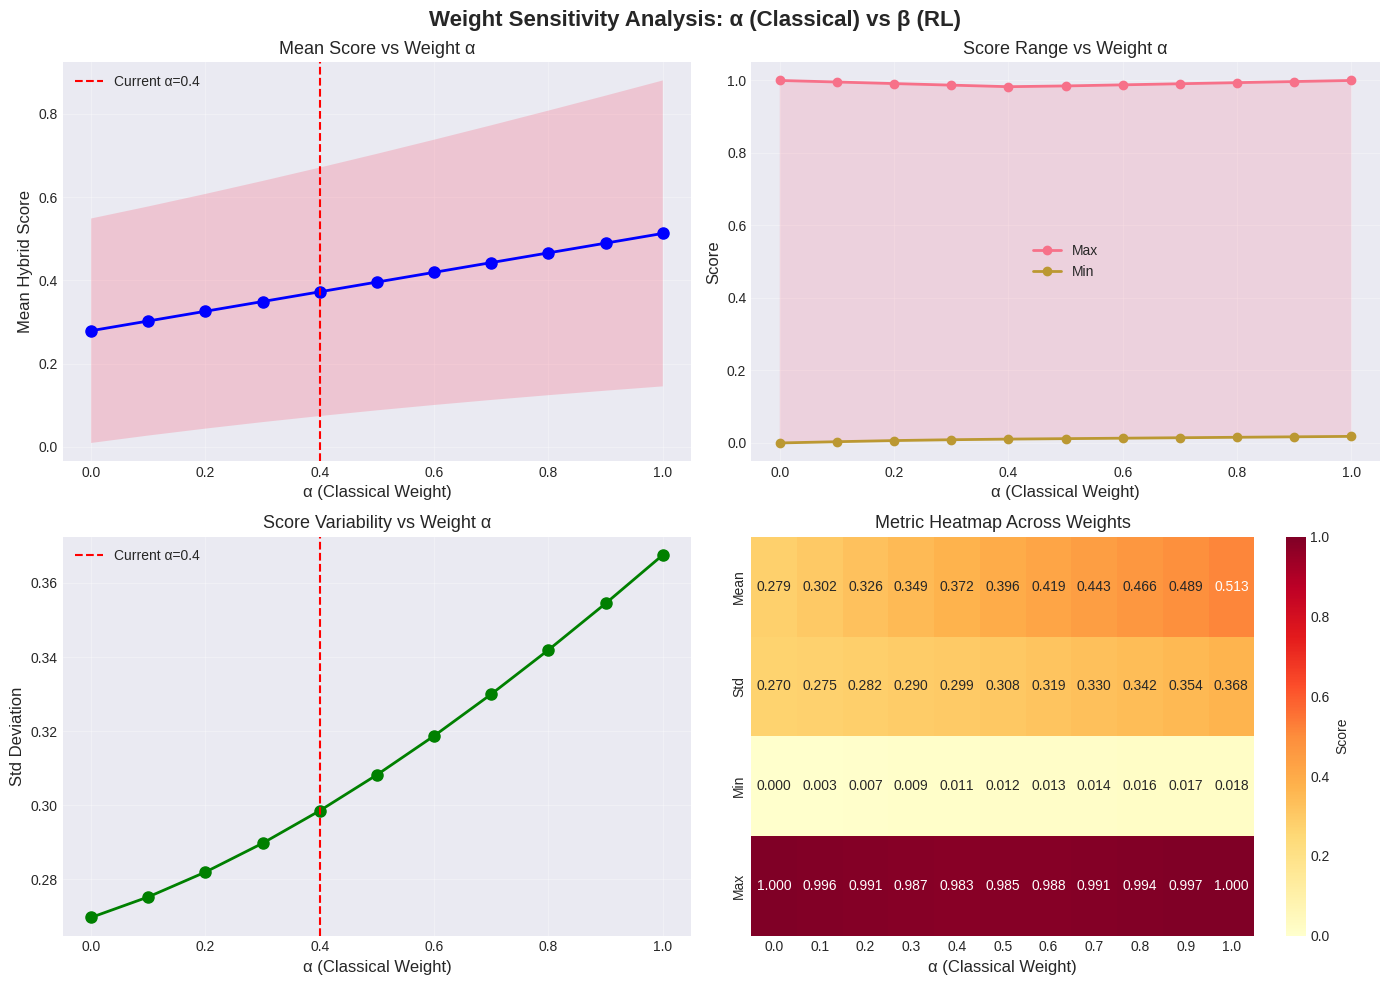

✓ Weight sensitivity plots saved


In [39]:
# ============================================================================
# CELL 12: Visualization 4 - Weight Sensitivity Analysis
# ============================================================================

def plot_weight_sensitivity(data: pd.DataFrame):
    """
    Analyze how different α, β weights affect the final hybrid score
    """
    # Test different weight combinations
    alphas = np.linspace(0, 1, 11)
    
    results = []
    for alpha in alphas:
        beta = 1 - alpha
        
        # Compute hybrid scores with these weights
        hybrid_scores = []
        for _, row in data.iterrows():
            classical = (row['bleu_score'] + row['rouge_score']) / 2
            rl = row['rl_return_norm']
            hybrid = alpha * classical + beta * rl
            hybrid_scores.append(hybrid)
        
        results.append({
            'alpha': alpha,
            'beta': beta,
            'mean_score': np.mean(hybrid_scores),
            'std_score': np.std(hybrid_scores),
            'min_score': np.min(hybrid_scores),
            'max_score': np.max(hybrid_scores)
        })
    
    results_df = pd.DataFrame(results)
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Weight Sensitivity Analysis: α (Classical) vs β (RL)', 
                 fontsize=16, fontweight='bold')
    
    # 1. Mean score vs alpha
    ax = axes[0, 0]
    ax.plot(results_df['alpha'], results_df['mean_score'], 
            marker='o', linewidth=2, markersize=8, color='blue')
    ax.fill_between(results_df['alpha'], 
                     results_df['mean_score'] - results_df['std_score'],
                     results_df['mean_score'] + results_df['std_score'],
                     alpha=0.3)
    ax.set_xlabel('α (Classical Weight)', fontsize=12)
    ax.set_ylabel('Mean Hybrid Score', fontsize=12)
    ax.set_title('Mean Score vs Weight α', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=0.4, color='red', linestyle='--', label='Current α=0.4')
    ax.legend()
    
    # 2. Score range vs alpha
    ax = axes[0, 1]
    ax.plot(results_df['alpha'], results_df['max_score'], 
            marker='o', label='Max', linewidth=2, markersize=6)
    ax.plot(results_df['alpha'], results_df['min_score'], 
            marker='o', label='Min', linewidth=2, markersize=6)
    ax.fill_between(results_df['alpha'], 
                     results_df['min_score'], 
                     results_df['max_score'],
                     alpha=0.2)
    ax.set_xlabel('α (Classical Weight)', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Score Range vs Weight α', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # 3. Std deviation vs alpha
    ax = axes[1, 0]
    ax.plot(results_df['alpha'], results_df['std_score'],
            marker='o', linewidth=2, markersize=8, color='green')
    ax.set_xlabel('α (Classical Weight)', fontsize=12)
    ax.set_ylabel('Std Deviation', fontsize=12)
    ax.set_title('Score Variability vs Weight α', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=0.4, color='red', linestyle='--', label='Current α=0.4')
    ax.legend()
    
    # 4. Heatmap showing all metrics
    ax = axes[1, 1]
    heatmap_data = results_df[['mean_score', 'std_score', 'min_score', 'max_score']].T
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[f'{a:.1f}' for a in alphas],
                yticklabels=['Mean', 'Std', 'Min', 'Max'],
                ax=ax, cbar_kws={'label': 'Score'})
    ax.set_xlabel('α (Classical Weight)', fontsize=12)
    ax.set_title('Metric Heatmap Across Weights', fontsize=13)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/weight_sensitivity.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Weight sensitivity plots saved")
    
    return results_df


sensitivity_results = plot_weight_sensitivity(eval_data)

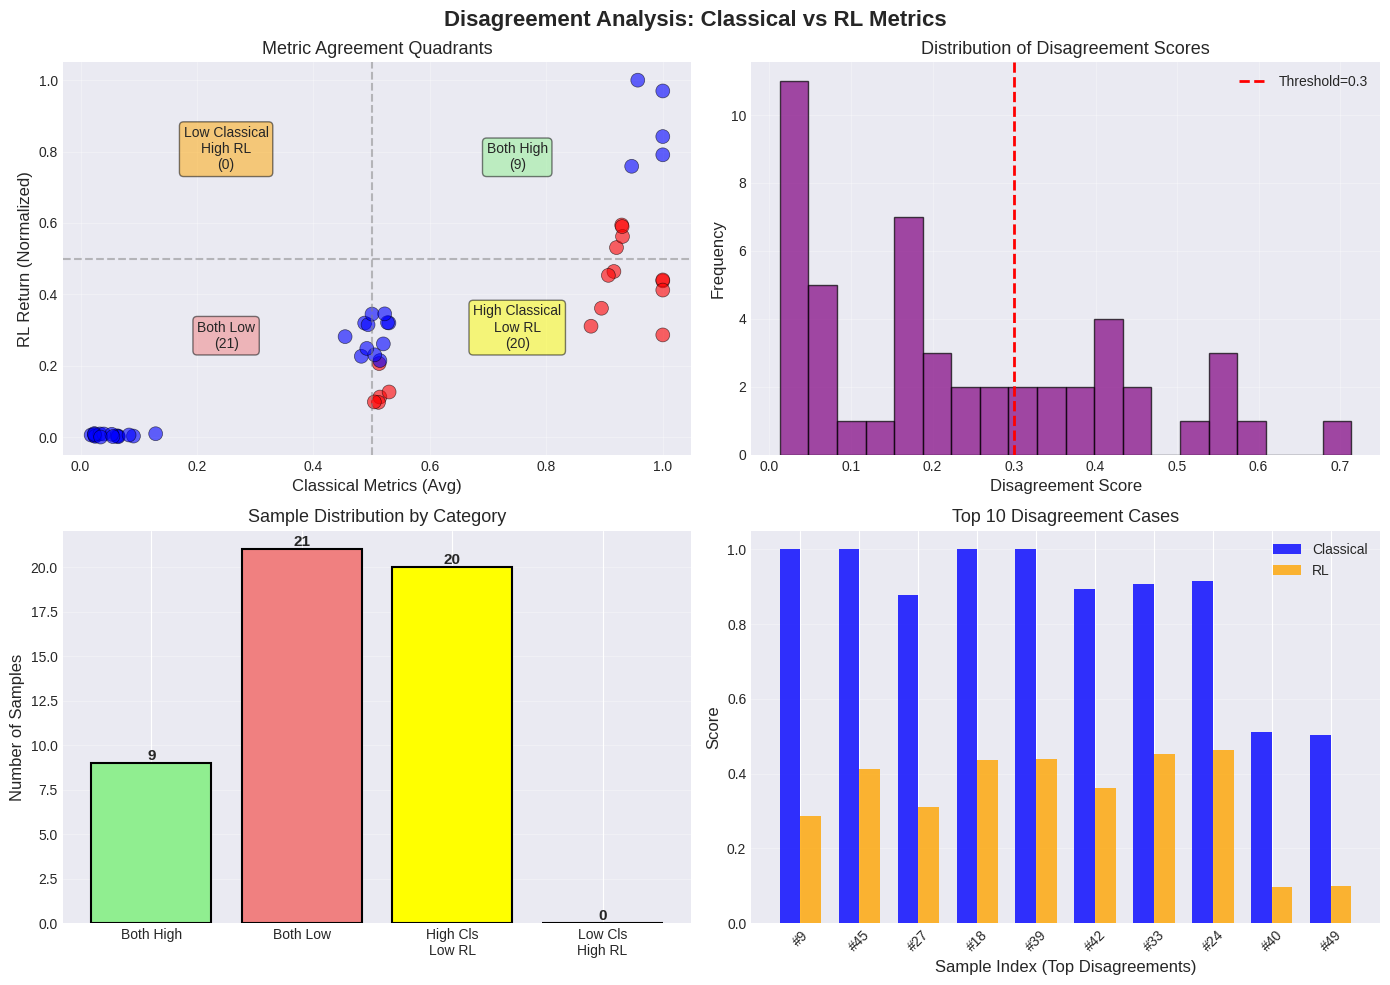

✓ Disagreement analysis plots saved

DISAGREEMENT ANALYSIS SUMMARY
Total samples: 50
High disagreement (>0.3): 17

Category breakdown:
  Both High (good):              9
  Both Low (needs improvement):  21
  High Classical, Low RL:        20
  Low Classical, High RL:        0


In [40]:
# ============================================================================
# CELL 13: Interpretability - Disagreement Analysis
# ============================================================================

def analyze_disagreements(data: pd.DataFrame, threshold=0.3):
    """
    Identify and analyze cases where classical and RL metrics disagree
    This helps with model debugging (Section 4.4 of paper)
    """
    # Calculate classical average
    data['classical_avg'] = (data['bleu_score'] + data['rouge_score']) / 2
    
    # Find disagreements
    data['disagreement'] = np.abs(data['classical_avg'] - data['rl_return_norm'])
    
    # Categorize samples
    high_classical_low_rl = data[
        (data['classical_avg'] > 0.5) & (data['rl_return_norm'] < 0.5)
    ]
    
    low_classical_high_rl = data[
        (data['classical_avg'] < 0.5) & (data['rl_return_norm'] > 0.5)
    ]
    
    both_high = data[
        (data['classical_avg'] > 0.5) & (data['rl_return_norm'] > 0.5)
    ]
    
    both_low = data[
        (data['classical_avg'] < 0.5) & (data['rl_return_norm'] < 0.5)
    ]
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Disagreement Analysis: Classical vs RL Metrics', 
                 fontsize=16, fontweight='bold')
    
    # 1. Scatter plot with quadrants
    ax = axes[0, 0]
    colors = ['red' if d > threshold else 'blue' for d in data['disagreement']]
    scatter = ax.scatter(data['classical_avg'], data['rl_return_norm'],
                        c=colors, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
    
    # Add quadrant lines
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    
    # Add quadrant labels
    ax.text(0.75, 0.75, f'Both High\n({len(both_high)})', 
            transform=ax.transData, ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    ax.text(0.25, 0.25, f'Both Low\n({len(both_low)})',
            transform=ax.transData, ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
    ax.text(0.75, 0.25, f'High Classical\nLow RL\n({len(high_classical_low_rl)})',
            transform=ax.transData, ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
    ax.text(0.25, 0.75, f'Low Classical\nHigh RL\n({len(low_classical_high_rl)})',
            transform=ax.transData, ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))
    
    ax.set_xlabel('Classical Metrics (Avg)', fontsize=12)
    ax.set_ylabel('RL Return (Normalized)', fontsize=12)
    ax.set_title('Metric Agreement Quadrants', fontsize=13)
    ax.grid(True, alpha=0.3)
    
    # 2. Disagreement distribution
    ax = axes[0, 1]
    ax.hist(data['disagreement'], bins=20, alpha=0.7, color='purple', edgecolor='black')
    ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Threshold={threshold}')
    ax.set_xlabel('Disagreement Score', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Disagreement Scores', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Category breakdown
    ax = axes[1, 0]
    categories = ['Both High', 'Both Low', 'High Cls\nLow RL', 'Low Cls\nHigh RL']
    counts = [len(both_high), len(both_low), len(high_classical_low_rl), 
              len(low_classical_high_rl)]
    colors_bar = ['lightgreen', 'lightcoral', 'yellow', 'orange']
    
    bars = ax.bar(categories, counts, color=colors_bar, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.set_title('Sample Distribution by Category', fontsize=13)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 4. Top disagreement samples
    ax = axes[1, 1]
    top_disagreements = data.nlargest(10, 'disagreement')
    x = np.arange(len(top_disagreements))
    width = 0.35
    
    ax.bar(x - width/2, top_disagreements['classical_avg'], width, 
           label='Classical', alpha=0.8, color='blue')
    ax.bar(x + width/2, top_disagreements['rl_return_norm'], width,
           label='RL', alpha=0.8, color='orange')
    
    ax.set_xlabel('Sample Index (Top Disagreements)', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Top 10 Disagreement Cases', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([f"#{i}" for i in top_disagreements.index], rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/disagreement_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Disagreement analysis plots saved")
    
    # Print summary
    print("\n" + "="*60)
    print("DISAGREEMENT ANALYSIS SUMMARY")
    print("="*60)
    print(f"Total samples: {len(data)}")
    print(f"High disagreement (>{threshold}): {len(data[data['disagreement'] > threshold])}")
    print(f"\nCategory breakdown:")
    print(f"  Both High (good):              {len(both_high)}")
    print(f"  Both Low (needs improvement):  {len(both_low)}")
    print(f"  High Classical, Low RL:        {len(high_classical_low_rl)}")
    print(f"  Low Classical, High RL:        {len(low_classical_high_rl)}")
    print("="*60)
    
    return {
        'both_high': both_high,
        'both_low': both_low,
        'high_classical_low_rl': high_classical_low_rl,
        'low_classical_high_rl': low_classical_high_rl
    }


disagreement_results = analyze_disagreements(eval_data, threshold=0.3)

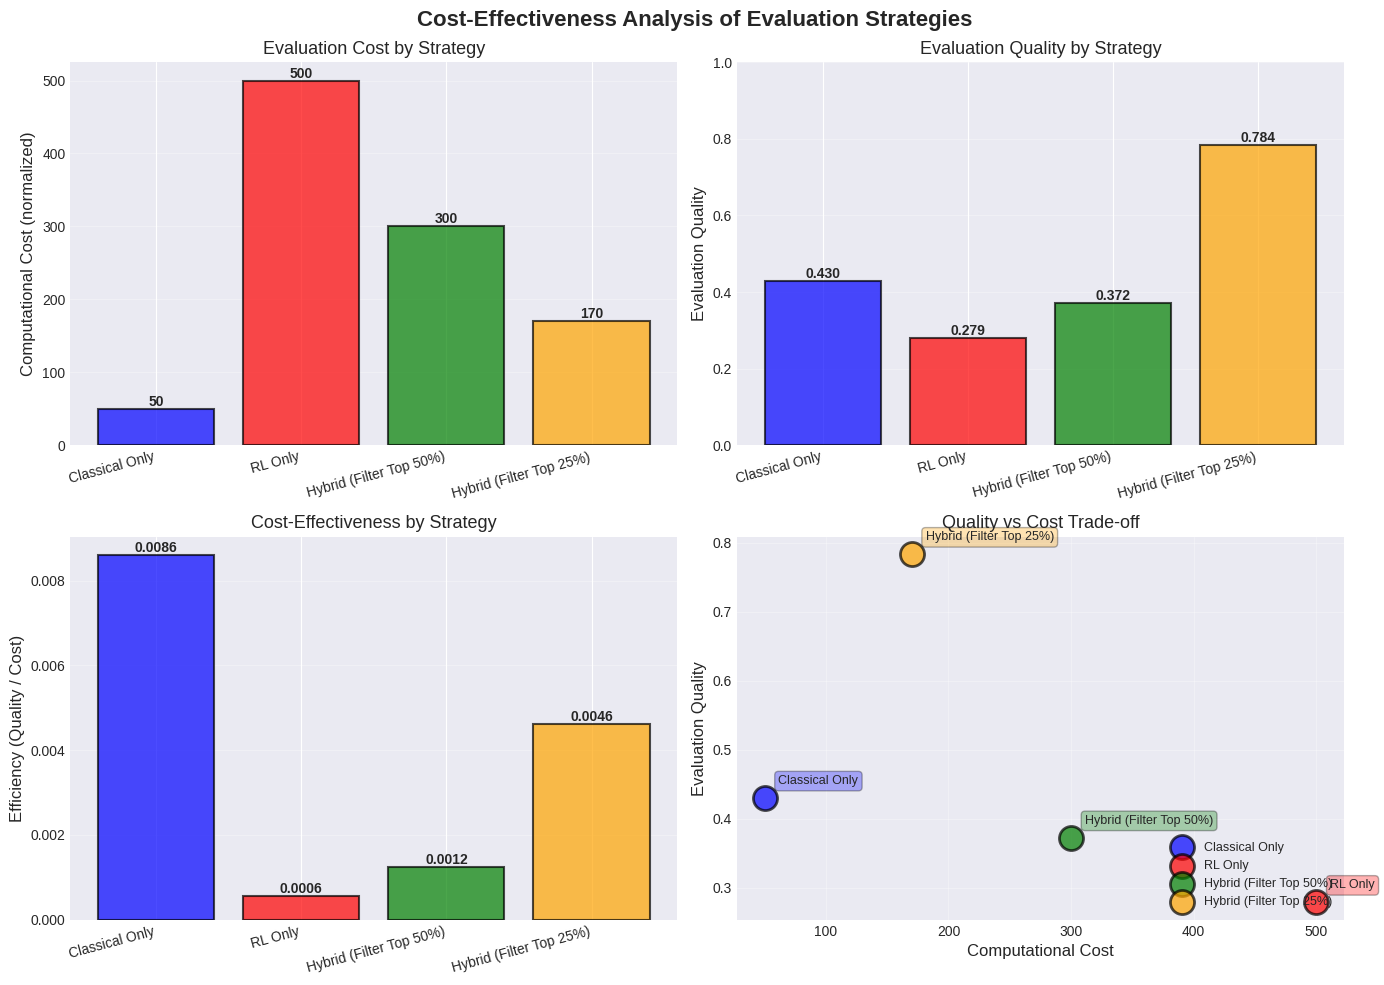

✓ Cost-effectiveness plots saved

COST-EFFECTIVENESS SUMMARY
                        cost   quality                          description efficiency
Classical Only            50  0.430107  Evaluate all with classical metrics   0.008602
RL Only                  500  0.278925                 Evaluate all with RL   0.000558
Hybrid (Filter Top 50%)  300  0.372457     Classical filter + RL on top 50%   0.001242
Hybrid (Filter Top 25%)  170  0.783549     Classical filter + RL on top 25%   0.004609


In [41]:
# ============================================================================
# CELL 14: Cost-Effectiveness Analysis
# ============================================================================

def plot_cost_effectiveness(data: pd.DataFrame):
    """
    Demonstrate cost-effectiveness of hybrid approach (Section 4.2 of paper)
    """
    # Simulate computational costs (normalized)
    classical_cost_per_sample = 1  # Fast, cheap
    rl_cost_per_sample = 10  # Expensive
    
    # Different evaluation strategies
    n_samples = len(data)
    
    strategies = {
        'Classical Only': {
            'cost': n_samples * classical_cost_per_sample,
            'quality': classical_scores['bleu'],  # Lower quality
            'description': 'Evaluate all with classical metrics'
        },
        'RL Only': {
            'cost': n_samples * rl_cost_per_sample,
            'quality': np.mean(eval_data['rl_return_norm']),  # High quality
            'description': 'Evaluate all with RL'
        },
        'Hybrid (Filter Top 50%)': {
            'cost': (n_samples * classical_cost_per_sample + 
                    (n_samples // 2) * rl_cost_per_sample),
            'quality': np.mean(eval_data['hybrid_score']),
            'description': 'Classical filter + RL on top 50%'
        },
        'Hybrid (Filter Top 25%)': {
            'cost': (n_samples * classical_cost_per_sample + 
                    (n_samples // 4) * rl_cost_per_sample),
            'quality': np.mean(eval_data.nlargest(n_samples//4, 'hybrid_score')['hybrid_score']),
            'description': 'Classical filter + RL on top 25%'
        }
    }
    
    # Create DataFrame
    strategy_df = pd.DataFrame(strategies).T
    strategy_df['efficiency'] = strategy_df['quality'] / strategy_df['cost']
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Cost-Effectiveness Analysis of Evaluation Strategies', 
                 fontsize=16, fontweight='bold')
    
    # 1. Cost comparison
    ax = axes[0, 0]
    colors_cost = ['blue', 'red', 'green', 'orange']
    bars = ax.bar(strategy_df.index, strategy_df['cost'], color=colors_cost, 
                  alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Computational Cost (normalized)', fontsize=12)
    ax.set_title('Evaluation Cost by Strategy', fontsize=13)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 2. Quality comparison
    ax = axes[0, 1]
    bars = ax.bar(strategy_df.index, strategy_df['quality'], color=colors_cost,
                  alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Evaluation Quality', fontsize=12)
    ax.set_title('Evaluation Quality by Strategy', fontsize=13)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1])
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 3. Efficiency (quality/cost)
    ax = axes[1, 0]
    bars = ax.bar(strategy_df.index, strategy_df['efficiency'], color=colors_cost,
                  alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Efficiency (Quality / Cost)', fontsize=12)
    ax.set_title('Cost-Effectiveness by Strategy', fontsize=13)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 4. Quality vs Cost scatter
    ax = axes[1, 1]
    for idx, (strategy, row) in enumerate(strategy_df.iterrows()):
        ax.scatter(row['cost'], row['quality'], s=300, 
                  color=colors_cost[idx], alpha=0.7, 
                  edgecolors='black', linewidth=2,
                  label=strategy)
        ax.annotate(strategy, (row['cost'], row['quality']),
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=9, bbox=dict(boxstyle='round', 
                   facecolor=colors_cost[idx], alpha=0.3))
    
    ax.set_xlabel('Computational Cost', fontsize=12)
    ax.set_ylabel('Evaluation Quality', fontsize=12)
    ax.set_title('Quality vs Cost Trade-off', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/cost_effectiveness.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Cost-effectiveness plots saved")
    
    print("\n" + "="*60)
    print("COST-EFFECTIVENESS SUMMARY")
    print("="*60)
    print(strategy_df.to_string())
    print("="*60)
    
    return strategy_df


cost_analysis = plot_cost_effectiveness(eval_data)

In [42]:
# ============================================================================
# CELL 15: Final Summary and Recommendations
# ============================================================================

def generate_final_report(data: pd.DataFrame, 
                         classical_scores: Dict,
                         sensitivity_results: pd.DataFrame,
                         cost_analysis: pd.DataFrame):
    """
    Generate comprehensive evaluation report
    """
    print("\n" + "="*70)
    print(" " * 15 + "HYBRID LLM EVALUATION - FINAL REPORT")
    print("="*70)
    
    print("\n📊 DATASET STATISTICS")
    print("-" * 70)
    print(f"Total samples evaluated:        {len(data)}")
    print(f"Average source length:          {np.mean([len(s) for s in data['source']]): .1f} chars")
    print(f"Average reference length:       {np.mean([len(s) for s in data['reference']]): .1f} chars")
    print(f"Average output length:          {np.mean([len(s) for s in data['model_output']]): .1f} chars")
    
    print("\n🎯 CLASSICAL METRICS PERFORMANCE")
    print("-" * 70)
    for metric, score in classical_scores.items():
        stars = "★" * int(score * 5)
        print(f"{metric.upper():20s}: {score:.4f}  {stars}")
    
    print("\n🤖 RL-BASED EVALUATION")
    print("-" * 70)
    print(f"Mean RL Return:                 {np.mean(data['rl_return_norm']):.4f}")
    print(f"Std RL Return:                  {np.std(data['rl_return_norm']):.4f}")
    print(f"Best sample return:             {np.max(data['rl_return_norm']):.4f}")
    print(f"Worst sample return:            {np.min(data['rl_return_norm']):.4f}")
    
    print("\n⚖️ HYBRID EVALUATION (α=0.4, β=0.6)")
    print("-" * 70)
    print(f"Mean Hybrid Score:              {np.mean(data['hybrid_score']):.4f}")
    print(f"Std Hybrid Score:               {np.std(data['hybrid_score']):.4f}")
    print(f"Best sample score:              {np.max(data['hybrid_score']):.4f}")
    print(f"Worst sample score:             {np.min(data['hybrid_score']):.4f}")
    
    # Best weight configuration
    best_config = sensitivity_results.loc[sensitivity_results['mean_score'].idxmax()]
    print("\n🎛️ OPTIMAL WEIGHT CONFIGURATION")
    print("-" * 70)
    print(f"Optimal α (classical):          {best_config['alpha']:.2f}")
    print(f"Optimal β (RL):                 {best_config['beta']:.2f}")
    print(f"Score with optimal weights:     {best_config['mean_score']:.4f}")
    
    # Cost analysis
    best_strategy = cost_analysis['efficiency'].idxmax()
    print("\n💰 COST-EFFECTIVENESS ANALYSIS")
    print("-" * 70)
    print(f"Most efficient strategy:        {best_strategy}")
    print(f"Efficiency score:               {cost_analysis.loc[best_strategy, 'efficiency']:.4f}")
    print(f"Quality score:                  {cost_analysis.loc[best_strategy, 'quality']:.4f}")
    print(f"Computational cost:             {cost_analysis.loc[best_strategy, 'cost']:.0f}")
    
    # Disagreement analysis
    disagreement_rate = len(data[data['disagreement'] > 0.3]) / len(data) * 100
    print("\n⚠️ DISAGREEMENT ANALYSIS")
    print("-" * 70)
    print(f"High disagreement rate:         {disagreement_rate:.1f}%")
    print(f"Avg disagreement score:         {np.mean(data['disagreement']):.4f}")
    
    # Recommendations
    print("\n💡 RECOMMENDATIONS")
    print("-" * 70)
    
    if np.mean(data['hybrid_score']) > 0.6:
        print("✓ Overall model performance is GOOD")
    elif np.mean(data['hybrid_score']) > 0.4:
        print("⚠ Overall model performance is MODERATE - consider improvements")
    else:
        print("✗ Overall model performance is POOR - significant improvements needed")
    
    if disagreement_rate > 30:
        print("⚠ High disagreement between classical and RL metrics")
        print("  → Review samples with high disagreement for insights")
    
    if best_config['alpha'] > 0.6:
        print(f"→ Classical metrics dominate (α={best_config['alpha']:.2f})")
        print("  Consider if task truly requires RL evaluation")
    elif best_config['beta'] > 0.6:
        print(f"→ RL evaluation dominates (β={best_config['beta']:.2f})")
        print("  Classical metrics may be less relevant for this task")
    
    print("\n📈 NEXT STEPS")
    print("-" * 70)
    print("1. Investigate high-disagreement samples for failure modes")
    print("2. Consider fine-tuning weights based on task requirements")
    print(f"3. Use '{best_strategy}' strategy for production evaluation")
    print("4. Monitor correlation between metrics over time")
    
    print("\n" + "="*70)
    print("Report generated successfully!")
    print("="*70 + "\n")


generate_final_report(eval_data, classical_scores, sensitivity_results, cost_analysis)


               HYBRID LLM EVALUATION - FINAL REPORT

📊 DATASET STATISTICS
----------------------------------------------------------------------
Total samples evaluated:        50
Average source length:           500.0 chars
Average reference length:        199.8 chars
Average output length:           116.4 chars

🎯 CLASSICAL METRICS PERFORMANCE
----------------------------------------------------------------------
BLEU                : 0.4301  ★★
ROUGE1              : 0.6068  ★★★
ROUGE2              : 0.5534  ★★
ROUGEL              : 0.5936  ★★
BERTSCORE           : 0.8630  ★★★★
PERPLEXITY          : 198.6396  ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

In [46]:
# ============================================================================
# CELL 16: Export Results
# ============================================================================

# Create comprehensive results DataFrame
results_df = eval_data[[
    'id', 'bleu_score', 'rouge_score', 'rl_return_norm', 
    'hybrid_score', 'disagreement', 'classical_avg'
]].copy()

# Save to CSV
results_df.to_csv('/kaggle/working/evaluation_results.csv', index=False)
print("✓ Results saved to evaluation_results.csv")

# Create summary statistics
summary_stats = pd.DataFrame({
    'Metric': ['BLEU', 'ROUGE-L', 'BERTScore', 'Perplexity', 
               'RL Return', 'Hybrid Score'],
    'Mean': [
        classical_scores['bleu'],
        classical_scores['rougeL'],
        classical_scores['bertscore'],
        classical_scores['perplexity'],
        np.mean(eval_data['rl_return_norm']),
        np.mean(eval_data['hybrid_score'])
    ],
    'Std': [
        np.std(eval_data['bleu_score']),
        np.std(eval_data['rouge_score']),
        0,  # Not computed per-sample
        0,  # Not computed per-sample
        np.std(eval_data['rl_return_norm']),
        np.std(eval_data['hybrid_score'])
    ]
})

summary_stats.to_csv('/kaggle/working/summary_statistics.csv', index=False)
print("✓ Summary statistics saved to summary_statistics.csv")

print("\n" + "="*70)
print("🎉 HYBRID LLM EVALUATION COMPLETE!")
print("="*70)
print("\nGenerated files:")
print("  1. evaluation_results.csv - Detailed per-sample results")
print("  2. summary_statistics.csv - Aggregated statistics")
print("  3. score_distributions.png - Score distribution plots")
print("  4. correlation_analysis.png - Correlation analysis")
print("  5. sample_analysis.png - Top/bottom performer analysis")
print("  6. weight_sensitivity.png - Weight sensitivity analysis")
print("  7. disagreement_analysis.png - Classical vs RL disagreement")
print("  8. cost_effectiveness.png - Cost-effectiveness comparison")
print("\n" + "="*70)

✓ Results saved to evaluation_results.csv
✓ Summary statistics saved to summary_statistics.csv

🎉 HYBRID LLM EVALUATION COMPLETE!

Generated files:
  1. evaluation_results.csv - Detailed per-sample results
  2. summary_statistics.csv - Aggregated statistics
  3. score_distributions.png - Score distribution plots
  4. correlation_analysis.png - Correlation analysis
  5. sample_analysis.png - Top/bottom performer analysis
  6. weight_sensitivity.png - Weight sensitivity analysis
  7. disagreement_analysis.png - Classical vs RL disagreement
  8. cost_effectiveness.png - Cost-effectiveness comparison

